In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Student Social Media And Mental Health Impact (1).csv")

In [ ]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [ ]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [ ]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [ ]:
df["Physical_Activity_Hours"] = df["Physical_Activity_Hours"].clip(lower=0)

In [ ]:
def sort_countries(country):
  countries = ['Other', 'India', 'USA', 'Canada', 'Australia', 'UK', 'Germany',
       'Mexico', 'Turkey', 'France']
  if country in countries:
    return country
  else:
    return "Other"

In [ ]:
df["Region"] = df["Country"].apply(sort_countries)
df = df.drop(axis=1, columns="Country")

<Axes: >

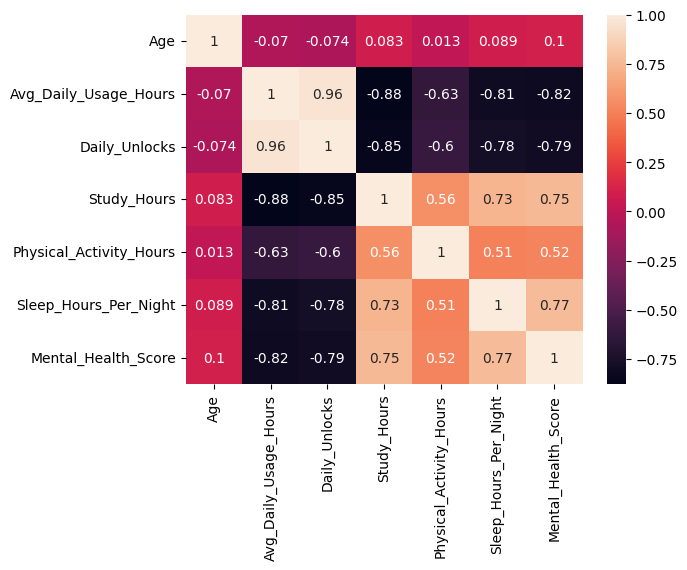

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

<Axes: xlabel='Study_Hours', ylabel='Count'>

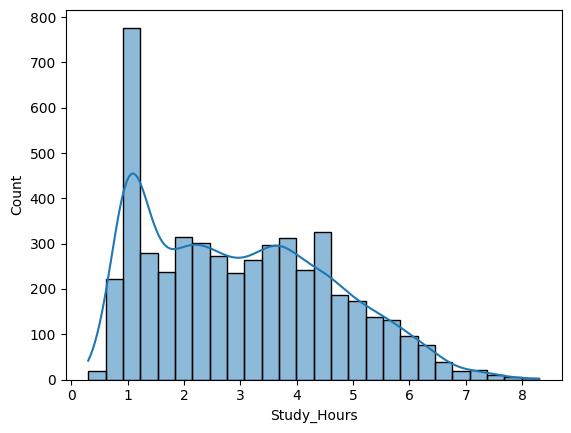

In [ ]:
sns.histplot(x="Study_Hours", kde=True, data=df)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.columns

Index(['Age', 'Gender', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score', 'Region'],
      dtype='object')

In [ ]:

from sklearn.model_selection import train_test_split

skew_cols = ["Study_Hours"]
normal_cols = ['Gender', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use', 'Region']
numeric_cols = ['Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night', 'Age']
ordinal_cols = ['Stress_Level']

feature_cols = skew_cols + normal_cols + numeric_cols + ordinal_cols
X = df[feature_cols]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer

skew_pipeline = Pipeline(steps = [
    ("log_transform", FunctionTransformer(np.log1p)),
    ("scale", StandardScaler())
])

normal_pipeline = Pipeline(steps = [
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

numeric_pipeline = Pipeline(steps = [
    ('scale',StandardScaler())
])

ordinal_pipeline = Pipeline(steps = [
    ('ordinal_encoding', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

preprocessor = ColumnTransformer(transformers=[
    ("Skewed_Pipeline", skew_pipeline, skew_cols),
    ("Plain_Numeric",numeric_pipeline, numeric_cols ),
    ('Ordinal', ordinal_pipeline, ordinal_cols),
    ('Normal', normal_pipeline, normal_cols)
])

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

lr_pipeline = Pipeline(steps = [
    ("preprocess", preprocessor),
    ("linear_regression", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_train_prediction = lr_pipeline.predict(X_train)
lr_test_prediction = lr_pipeline.predict(X_test)

lr_train_score = r2_score(y_train, lr_train_prediction)
lr_test_score = r2_score(y_test, lr_test_prediction)
print(f"Training r2 score: {lr_train_score}")
print(f"Testing r2 score: {lr_test_score}")

Training r2 score: 0.7236771199387539
Testing r2 score: 0.7397944617433021


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps = [
    ('preprocess', preprocessor),
    ('rf_regression', RandomForestRegressor())
])

rf_pipeline.fit(X_train, y_train)
rf_train_prediction = rf_pipeline.predict(X_train)
rf_test_prediction = rf_pipeline.predict(X_test)

rf_train_r2_score = r2_score(y_train, rf_train_prediction)
rf_test_r2_score = r2_score(y_test, rf_test_prediction)

print(f'Random Forest Regression Training data r2 Score: {rf_train_r2_score}')
print(f'Random Forest Regression Testing data r2 Score: {rf_test_r2_score}')

Random Forest Regression Training data r2 Score: 0.9812260505301631
Random Forest Regression Testing data r2 Score: 0.8769698338363262


In [ ]:
import joblib

joblib.dump(rf_pipeline, "MentalHealthPredictor.pkl")

['MentalHealthPredictor.pkl']

In [ ]:
import sklearn
sklearn.__version__

'1.6.1'